# SWOT along-track SSH spectra in 2°×2° boxes

This notebook:
1. Loads all SWOT L2 LR SSH Expert granules from a local directory.
2. Computes along-track SSH(A) wavenumber spectra for every granule (both KaRIn swaths, left and right) using `compute_pass_spectra` from `swot_analysis`.
3. Collects every retained segment across all files and both swaths into a single flat `xarray.Dataset`.
4. Assigns each segment to a 2°×2° geographic box based on its mean latitude/longitude.
5. Computes the mean PSD per box and packages the results as an `xarray.Dataset` indexed by box.
6. Produces diagnostic figures: integrated PSD, zonal / meridional means, umber of segments per bin,etc.
   
**Expert vs Basic product:** The Expert product (`SWOT_L2_LR_SSH_Expert`) carries the full set of geophysical corrections and expert-level quality flags (`ssha_karin_2_qual`, `ancillary_surface_classification_flag`, `surface_type`). The loader below applies those flags before passing data to the spectral routines, which otherwise remain identical to the Basic-product workflow.

In [1]:
import glob
import os
import warnings
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from tqdm.auto import tqdm

from swot_analysis import compute_pass_spectra

## 1. Configuration

In [2]:
# ── Input files ──────────────────────────────────────────────────────────────
DATA_DIR = '/Users/zoecas/Documents/data/'
DATA_SUBDIR = "GSER_0225/" # directory containing Expert .nc files
FILE_PATTERN = "SWOT_L2_LR_SSH_Expert_*.nc"

# ── Region of interest ───────────────────────────────────────────────────────
# Segments whose mean lat/lon fall outside this box are silently skipped.
# Set to global extents (-90/90, 0/360) to keep everything.
LAT_MIN, LAT_MAX = -33.0, -3.0
LON_MIN, LON_MAX = 95.0, 145.0

# ── Spectral parameters ───────────────────────────────────────────────────────
SEGMENT_LENGTH_KM = 250.0   # along-track segment length in km
OVERLAP           = 0.5     # fractional overlap between consecutive segments
MAX_GAP_FRACTION  = 0.25    # max NaN/land fraction per pixel column per segment

# ── Box size ─────────────────────────────────────────────────────────────────
BOX_DEG = 2.0               # box side length in degrees (2° × 2°)

# ── Expert-product variable names ────────────────────────────────────────────
# In the Expert product the recommended SSHA variable is ssha_karin_2;
# change to ssh_karin_2 for absolute SSH or ssha_karin for the unsmoothed field.
SSH_VAR = "ssha_karin_2"

## 2. Loading data

Differences from the Basic-product loader in `swot_analysis`:
- Applies `ssha_karin_2_qual` (bit-flag, keep only `qual == 0`) and, if present, `ancillary_surface_classification_flag` to mask land/ice.
- Reads `surface_type` to additionally mask inland-water pixels (surface_type > 0).
- Falls back gracefully if any of those optional variables are absent.

In [3]:
def load_swot_l2_expert(filepath: str, ssh_var: str = "ssha_karin_2", HRET: bool = True) -> dict:
    """
    Load the SWOT L2 LR SSH Expert granule at `filepath` and return a dict
    ready for compute_pass_spectra():
        ssha, latitude, longitude, cross_track_distance

    Expert-specific masking applied (in order):
      1. ssha_karin_2_qual == 0  (recommended quality flag for Expert)
      2. ancillary_surface_classification_flag == 0  (open ocean only)
      3. surface_type == 0  (open ocean; drops inland water if present)
    If these masks are not found, data will still be loaded (even though degraded)
    """
    ds = xr.open_dataset(filepath)
    if HRET:
        ssha = (ds[ssh_var]+ds["height_cor_xover"]+ds["internal_tide_hret"]).values.astype(float)
    else:
        ssha = (ds[ssh_var]+ds["height_cor_xover"]).values.astype(float)

    # 1. Expert quality flag
    for qual_name in (f"{ssh_var}_qual", "ssha_karin_2_qual", "ssh_karin_2_qual"):
        if qual_name in ds.variables:
            qual = ds[qual_name].values
            ssha = np.where(qual == 0, ssha, np.nan)
            break

    # 2. Surface classification (0 = open ocean)
    for scf_name in ("ancillary_surface_classification_flag", "surface_classification_flag"):
        if scf_name in ds.variables:
            scf = ds[scf_name].values
            ssha = np.where(scf == 0, ssha, np.nan)
            break

    # 3. Surface type (0 = open ocean; masks lakes, rivers, etc.)
    if "surface_type" in ds.variables:
        stype = ds["surface_type"].values
        ssha = np.where(stype == 0, ssha, np.nan)

    lat  = ds["latitude"].values.astype(float)
    lon  = ds["longitude"].values.astype(float)
    xt   = ds["cross_track_distance"].values.astype(float)

    ds.close()
    return {"ssha": ssha, "latitude": lat, "longitude": lon, "cross_track_distance": xt}

## 3. Convert a list of SegmentSpectrum objects to an xarray dataset

In [4]:
def segments_to_dataset(all_segments: list, wavenumber: np.ndarray) -> xr.Dataset:
    """
    Pack a flat list of SegmentSpectrum objects (from any number of
    granules / swaths) into a single xarray.Dataset with dims
    (segment, wavenumber).

    `wavenumber` must be the shared wavenumber axis (cycles/km).
    All segments must share this axis (guaranteed when segment_length_km
    and along_track_spacing are consistent across files).
    """
    if not all_segments:
        raise ValueError("No segments to pack.")

    psd = np.stack([s.psd for s in all_segments], axis=0)  # (N, nk)

    return xr.Dataset(
        data_vars=dict(
            psd=(["segment", "wavenumber"], psd,
                 {"long_name": "Along-track SSH(A) PSD",
                  "units": "m^2 / (cycles/km)"}),
            lat_mean=(["segment"], [s.lat_mean for s in all_segments],
                      {"units": "degrees_north"}),
            lat_min=(["segment"], [s.lat_min for s in all_segments],
                     {"units": "degrees_north"}),
            lat_max=(["segment"], [s.lat_max for s in all_segments],
                     {"units": "degrees_north"}),
            lon_mean=(["segment"], [s.lon_mean for s in all_segments],
                      {"units": "degrees_east"}),
            n_pixels_used=(["segment"], [s.n_pixels_used for s in all_segments]),
            valid_fraction=(["segment"], [s.valid_fraction for s in all_segments]),
            swath=(["segment"], [s.swath for s in all_segments]),
            granule=(["segment"], [s._granule for s in all_segments]),
        ),
        coords=dict(
            wavenumber=("wavenumber", wavenumber, {"units": "cycles/km"}),
            segment=("segment", np.arange(len(all_segments))),
        ),
    )

## 4. Assign segments to 2°×2° boxes and compute box mean spectra

In [5]:
def build_box_dataset(ds_segments: xr.Dataset, box_deg: float = 2.0) -> xr.Dataset:
    """
    Group segments by (lat_box, lon_box) and compute the mean PSD and
    segment count per 2°×2° box.

    Returns an xr.Dataset with dims (box, wavenumber) and per-box
    coordinates lat_center, lon_center, n_segments.
    """
    lat = ds_segments["lat_mean"].values
    lon = ds_segments["lon_mean"].values

    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)
    box_keys = list(zip(lat_idx, lon_idx))

    from collections import defaultdict
    box_to_segs = defaultdict(list)
    for i, key in enumerate(box_keys):
        box_to_segs[key].append(i)

    psd_all = ds_segments["psd"].values  # (N, nk)
    wavenumber = ds_segments["wavenumber"].values

    rows_lat_center, rows_lon_center, rows_n, rows_psd = [], [], [], []
    box_lat_idx_out, box_lon_idx_out = [], []

    for (li, loi), seg_indices in sorted(box_to_segs.items()):
        seg_psd = psd_all[seg_indices, :]           # (n_in_box, nk)
        rows_psd.append(np.nanmean(seg_psd, axis=0))
        rows_n.append(len(seg_indices))
        rows_lat_center.append((li + 0.5) * box_deg)
        rows_lon_center.append((loi + 0.5) * box_deg)
        box_lat_idx_out.append(li)
        box_lon_idx_out.append(loi)

    mean_psd = np.stack(rows_psd, axis=0)  # (n_boxes, nk)

    return xr.Dataset(
        data_vars=dict(
            mean_psd=(["box", "wavenumber"], mean_psd,
                      {"long_name": "Box-mean along-track SSH(A) PSD",
                       "units": "m^2 / (cycles/km)"}),
            n_segments=(["box"], rows_n,
                        {"long_name": "Number of segments in box"}),
            lat_center=(["box"], rows_lat_center,
                        {"long_name": "Box centre latitude", "units": "degrees_north"}),
            lon_center=(["box"], rows_lon_center,
                        {"long_name": "Box centre longitude", "units": "degrees_east"}),
            lat_idx=(["box"], box_lat_idx_out),
            lon_idx=(["box"], box_lon_idx_out),
        ),
        coords=dict(
            wavenumber=("wavenumber", wavenumber, {"units": "cycles/km"}),
            box=("box", np.arange(len(rows_n))),
        ),
        attrs=dict(
            box_size_deg=box_deg,
            description=f"Mean along-track SSH(A) wavenumber PSD in {box_deg}°×{box_deg}° boxes.",
        ),
    )

## 5. Load every granule and collect segments

Warning: This method uses a serial loop. It is likely to break when running over heavy datasets

In [6]:
filepaths = sorted(glob.glob(os.path.join(DATA_DIR,DATA_SUBDIR, FILE_PATTERN)))
print(f"{len(filepaths)} Expert granule files found.")

all_segments = []   # flat list of SegmentSpectrum (across all files + swaths)
wavenumber   = None # set on first successful file
skipped      = []   # files that raised an exception

for fp in tqdm(filepaths, desc="Processing granules", unit="file"):
    try:
        data = load_swot_l2_expert(fp, ssh_var=SSH_VAR)
    except Exception as exc:
        skipped.append((fp, str(exc)))
        continue

    try:
        result = compute_pass_spectra(
            ssha=data["ssha"],
            latitude=data["latitude"],
            longitude=data["longitude"],
            cross_track_distance=data["cross_track_distance"],
            segment_length_km=SEGMENT_LENGTH_KM,
            overlap=OVERLAP,
            max_gap_fraction=MAX_GAP_FRACTION,
        )
    except Exception as exc:
        skipped.append((fp, str(exc)))
        continue
    
    granule_name = Path(fp).stem
    for swath_name, res in result.items():
        #print(res.n_segments_used)
        if res.n_segments_used == 0:
            continue
        if wavenumber is None:
            wavenumber = res.wavenumber

        for seg in res.segments:
            # Filter to region of interest by segment mean lat/lon
            if (LAT_MIN <= seg.lat_mean <= LAT_MAX) and (LON_MIN <= seg.lon_mean <= LON_MAX):
                # Attach a granule label for provenance (added as an attribute)
                seg._granule = granule_name
                all_segments.append(seg)
            else:
                continue
            
            

print(f"\nDone. {len(all_segments)} segments retained in region, "
      f"{len(skipped)} file(s) skipped.")
if skipped:
    print("Skipped files:")
    for fp, err in skipped:
        print(f"  {Path(fp).name}: {err}")

136 Expert granule files found.


Processing granules:   0%|          | 0/136 [00:00<?, ?file/s]


Done. 23 segments retained in region, 0 file(s) skipped.


## 6. Build the xarray dataset and the 2°×2° box dataset

In [7]:
if not all_segments:
    raise RuntimeError("No segments retained — check the region bounds, "
                        "file pattern, and SSH variable name.")

ds_segments = segments_to_dataset(all_segments, wavenumber)
print(f"Segment dataset: {ds_segments.sizes}")

ds_boxes = build_box_dataset(ds_segments, box_deg=BOX_DEG)
print(f"Box dataset: {ds_boxes.sizes['box']} boxes with at least 1 segment")
ds_boxes

Segment dataset: Frozen({'segment': 23, 'wavenumber': 63})
Box dataset: 18 boxes with at least 1 segment


<xarray.Dataset> Size: 10kB
Dimensions:     (box: 18, wavenumber: 63)
Coordinates:
  * box         (box) int64 144B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17
  * wavenumber  (wavenumber) float64 504B 0.0 0.003998 ... 0.2439 0.2479
Data variables:
    mean_psd    (box, wavenumber) float64 9kB 0.01109 0.02264 ... 1.328e-05
    n_segments  (box) int64 144B 1 1 1 1 1 3 1 2 1 1 2 2 1 1 1 1 1 1
    lat_center  (box) float64 144B -33.0 -33.0 -31.0 -31.0 ... -11.0 -9.0 -7.0
    lon_center  (box) float64 144B 109.0 111.0 109.0 111.0 ... 107.0 107.0 105.0
    lat_idx     (box) int64 144B -17 -17 -16 -16 -15 -14 ... -8 -7 -7 -6 -5 -4
    lon_idx     (box) int64 144B 54 55 54 55 54 54 53 ... 53 53 52 53 53 53 52
Attributes:
    box_size_deg:  2.0
    description:   Mean along-track SSH(A) wavenumber PSD in 2.0°×2.0° boxes.

## 7. Diagnostics: segment count and coverage

In [8]:
print("Segments per swath:")
for sw in ("left", "right"):
    n = int((ds_segments["swath"] == sw).sum())
    print(f"  {sw}: {n}")
print(f"\nBoxes with ≥ 5 segments:  {int((ds_boxes['n_segments'] >= 5).sum())}")
print(f"Boxes with ≥ 10 segments: {int((ds_boxes['n_segments'] >= 10).sum())}")
print(f"Max segments in a box:    {int(ds_boxes['n_segments'].max())}")

Segments per swath:
  left: 12
  right: 11

Boxes with ≥ 5 segments:  0
Boxes with ≥ 10 segments: 0
Max segments in a box:    3


## 8. General diagnostics: Along-track SSHA for swaths and mean PSD

In [9]:
good_files = [DATA_DIR+DATA_SUBDIR+granule for granule in np.unique(ds_segments.granule)+'.nc']

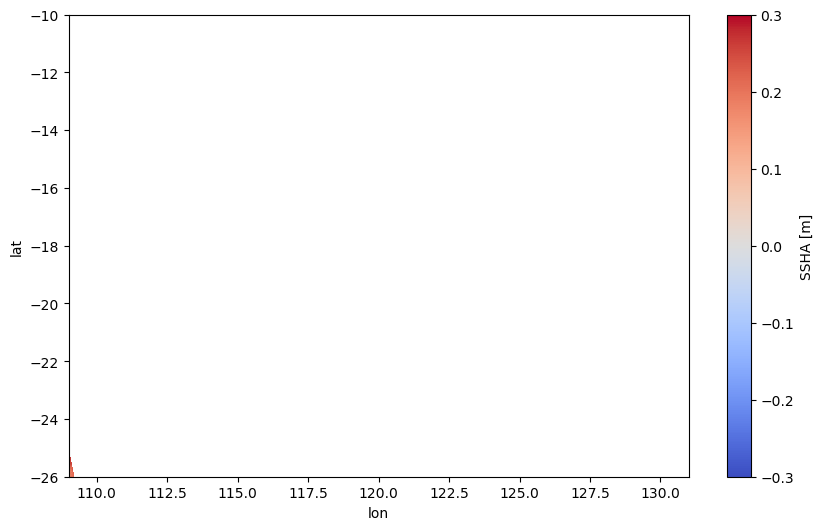

In [10]:
# Plot SSHA
title = 'SSHA [m]'
fig,ax = plt.subplots(figsize=(10,6))
for f in good_files:
    data = load_swot_l2_expert(f, ssh_var=SSH_VAR)
    _ds = xr.Dataset({'ssha':(['num_lines','num_pixels'],data['ssha']),
            'lon':(['num_lines','num_pixels'],data['longitude']),
           'lat':(['num_lines','num_pixels'],data['latitude'])})
    _ds = _ds.assign_coords({'lat':_ds.lat,'lon':_ds.lon})
    cm = _ds.ssha.plot.pcolormesh(ax=ax,x='lon',y='lat',vmax=0.3,cmap='coolwarm',add_colorbar=False)
    #ax.pcolormesh(data['longitude'],data['latitude'],data['ssha'])
ax.set_xlim(LON_MIN+14,LON_MAX-14);
ax.set_ylim(LAT_MIN+7,LAT_MAX-7);
plt.colorbar(cm,ax=ax,label='SSHA [m]')

/Users/zoecas/Documents/data/NWS_0225/SWOT_L2_LR_SSH_Expert_028_562_20250223T145243_20250223T154411_PGD0_02.nc


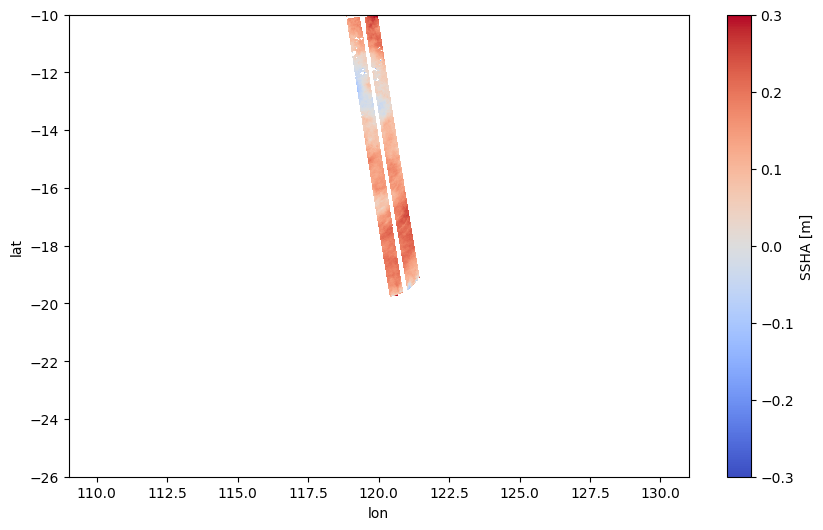

In [36]:
#Hunting down internal waves:
if True:
    f = good_files[88]
    fig,ax = plt.subplots(figsize=(10,6))
    data = load_swot_l2_expert(f, ssh_var=SSH_VAR)
    _ds = xr.Dataset({'ssha':(['num_lines','num_pixels'],data['ssha']),
                'lon':(['num_lines','num_pixels'],data['longitude']),
               'lat':(['num_lines','num_pixels'],data['latitude'])})
    _ds = _ds.assign_coords({'lat':_ds.lat,'lon':_ds.lon})
    cm = _ds.ssha.plot.pcolormesh(ax=ax,x='lon',y='lat',vmax=0.3,cmap='coolwarm',add_colorbar=False)
    ax.set_xlim(LON_MIN+14,LON_MAX-14);
    ax.set_ylim(LAT_MIN+7,LAT_MAX-7);
    plt.colorbar(cm,ax=ax,label='SSHA [m]')
    print(f)

239 boxes with ≥ 5 segments


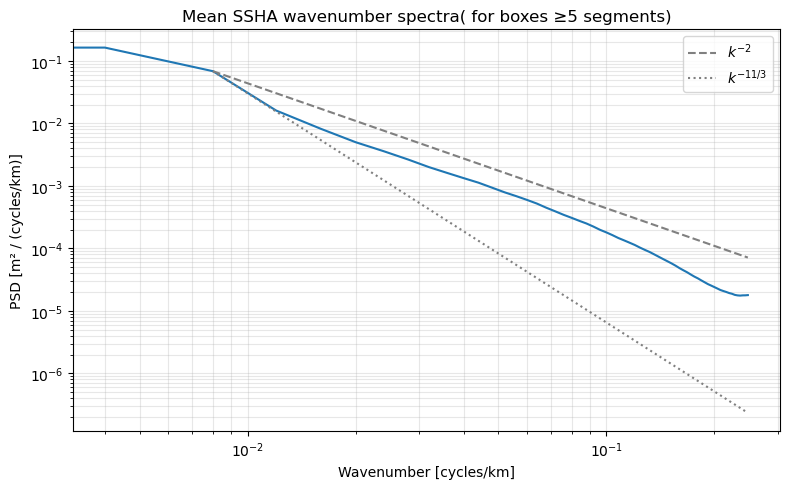

In [27]:
# For all latitudes
MIN_SEGMENTS_PER_BOX = 5

good_boxes = ds_boxes.where(ds_boxes["n_segments"] >= MIN_SEGMENTS_PER_BOX, drop=True)
#good_boxes = good_boxes.where((good_boxes["lat_center"] >= LAT_MIN)&(good_boxes["lat_center"] <= LAT_MAX), drop=True)
print(f"{good_boxes.sizes['box']} boxes with ≥ {MIN_SEGMENTS_PER_BOX} segments")

lat_vals = good_boxes["lat_center"].values
norm = plt.Normalize(vmin=lat_vals.min(), vmax=lat_vals.max())
cmap = plt.get_cmap("viridis")

fig, ax = plt.subplots(figsize=(8, 5))

good_boxes.mean('box').mean_psd.plot(yscale='log',xscale='log')
# Reference slopes
k_ref = good_boxes["wavenumber"].values[2:]
psd0  = float(good_boxes["mean_psd"].mean('box').values[2])
k0    = k_ref[0]
for exp, ls in ((-2, "--"), (-11/3, ":")):
    lbl = f"$k^{{{exp:.2g}}}$".replace("-3.7", "-11/3")
    ax.loglog(k_ref, psd0 * (k_ref / k0) ** exp, ls, color="gray", label=lbl)

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra"
             f"( for boxes ≥{MIN_SEGMENTS_PER_BOX} segments)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()



## 9. Map: number of segments per box

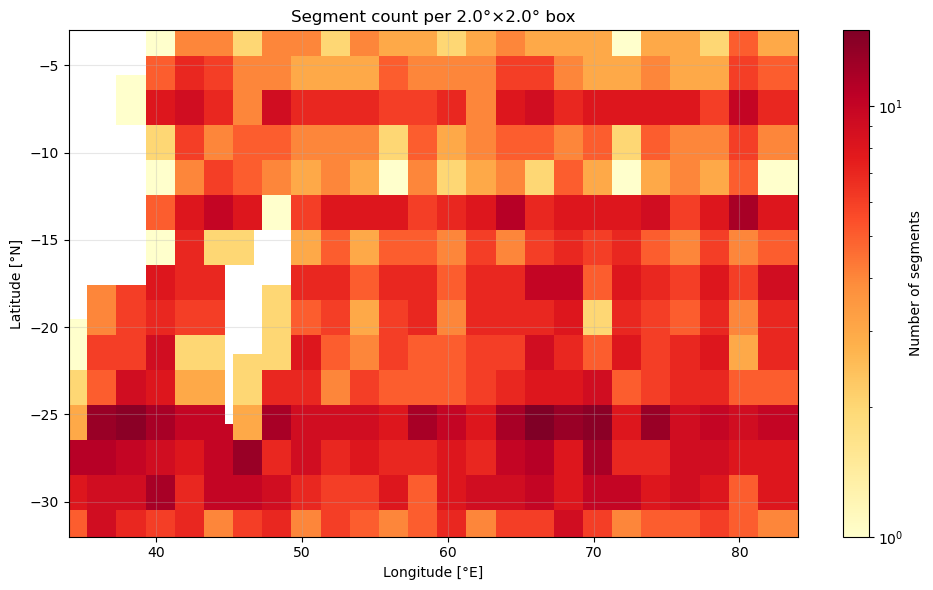

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    ds_boxes["lon_center"].values,
    ds_boxes["lat_center"].values,
    c=ds_boxes["n_segments"].values,
    s=(BOX_DEG * 60) ** 1.5,   # square-ish markers scaled to box size
    marker="s",
    cmap="YlOrRd",
    norm=mcolors.LogNorm(vmin=1, vmax=float(ds_boxes["n_segments"].max())),
    edgecolors="none",
)
plt.colorbar(sc, ax=ax, label="Number of segments")
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_xlabel("Longitude [°E]")
ax.set_ylabel("Latitude [°N]")
ax.set_title(f"Segment count per {BOX_DEG}°×{BOX_DEG}° box")
ax.grid(True, alpha=0.3)
fig.tight_layout()

## 10. Maps: integrated spectral energy per box (proxy for SSH variability)

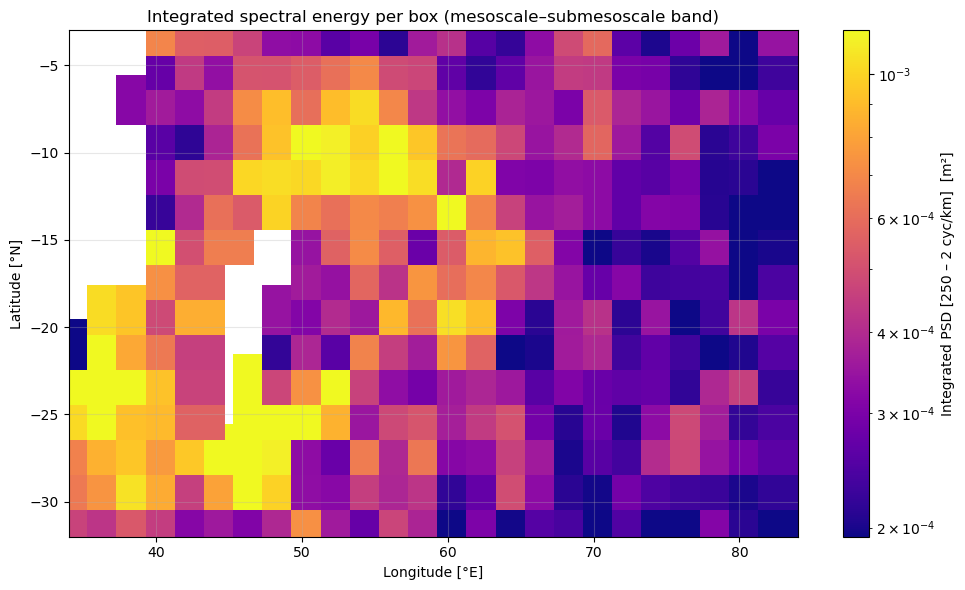

In [29]:
# Integrate the mean PSD over the mesoscale-submesoscale wavenumber band.

K_MIN, K_MAX = 1/250, 1/2  # cycles/km

k = ds_boxes["wavenumber"].values
k_mask = (k >= K_MIN) & (k <= K_MAX)
dk = np.gradient(k)

psd_vals = ds_boxes["mean_psd"].values          # (n_boxes, nk)
energy = np.nansum(psd_vals[:, k_mask] * dk[k_mask], axis=1)  # (n_boxes,)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    ds_boxes["lon_center"].values,
    ds_boxes["lat_center"].values,
    c=energy,
    s=(BOX_DEG * 60) ** 1.5,
    marker="s",
    cmap="plasma",
    norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                          vmax=np.nanpercentile(energy, 95)),
    edgecolors="none",
)
plt.colorbar(sc, ax=ax, label=f"Integrated PSD [{1/K_MIN:.0f} – {1/K_MAX:.0f} cyc/km]  [m²]")
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_xlabel("Longitude [°E]")
ax.set_ylabel("Latitude [°N]")
ax.set_title("Integrated spectral energy per box (mesoscale–submesoscale band)")
ax.grid(True, alpha=0.3)
fig.tight_layout()

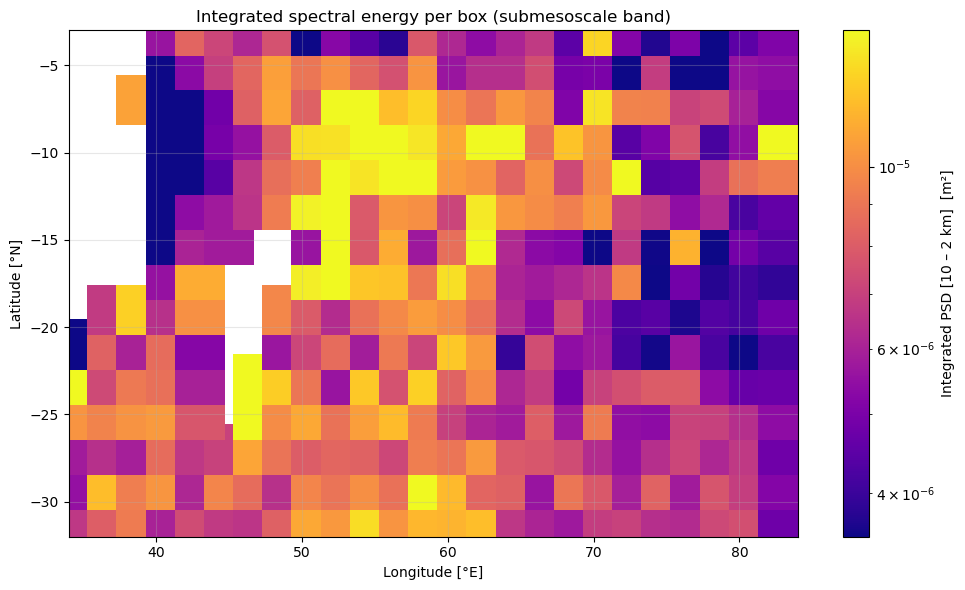

In [30]:
# Integrate the mean PSD over the submesoscale wavenumber band
K_MIN, K_MAX = 1/10, 1/2  # cycles/km

k = ds_boxes["wavenumber"].values
k_mask = (k >= K_MIN) & (k <= K_MAX)
dk = np.gradient(k)

psd_vals = ds_boxes["mean_psd"].values          # (n_boxes, nk)
energy = np.nansum(psd_vals[:, k_mask] * dk[k_mask], axis=1)  # (n_boxes,)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    ds_boxes["lon_center"].values,
    ds_boxes["lat_center"].values,
    c=energy,
    s=(BOX_DEG * 60) ** 1.5,
    marker="s",
    cmap="plasma",
    norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                          vmax=np.nanpercentile(energy, 95)),
    edgecolors="none",
)
plt.colorbar(sc, ax=ax, label=f"Integrated PSD [{1/K_MIN:.0f} – {1/K_MAX:.0f} km]  [m²]")
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_xlabel("Longitude [°E]")
ax.set_ylabel("Latitude [°N]")
ax.set_title("Integrated spectral energy per box (submesoscale band)")
ax.grid(True, alpha=0.3)
fig.tight_layout()

## 11. Spectra: mean PSD per box, coloured by latitude and longitude

Boxes with fewer than `MIN_SEGMENTS_PER_BOX` segments are excluded to avoid noisy estimates.

239 boxes with ≥ 5 segments


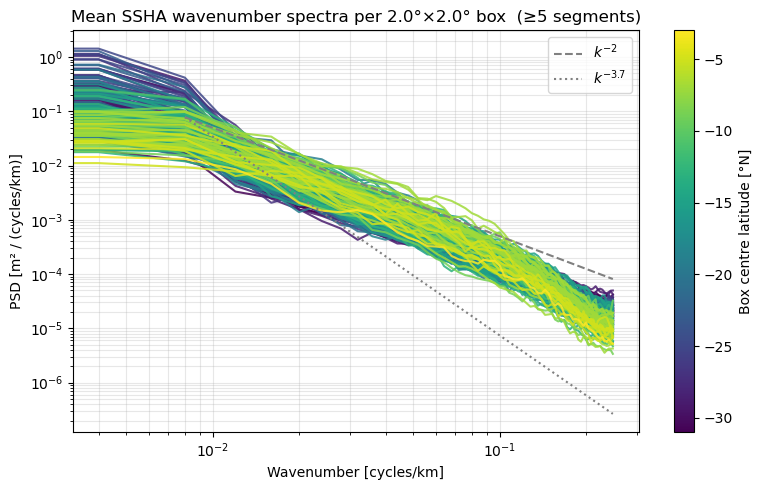

In [31]:
# For all latitudes
MIN_SEGMENTS_PER_BOX = 5

good_boxes = ds_boxes.where(ds_boxes["n_segments"] >= MIN_SEGMENTS_PER_BOX, drop=True)
#good_boxes = good_boxes.where((good_boxes["lat_center"] >= LAT_MIN)&(good_boxes["lat_center"] <= LAT_MAX), drop=True)
print(f"{good_boxes.sizes['box']} boxes with ≥ {MIN_SEGMENTS_PER_BOX} segments")

lat_vals = good_boxes["lat_center"].values
norm = plt.Normalize(vmin=lat_vals.min(), vmax=lat_vals.max())
cmap = plt.get_cmap("viridis")

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(good_boxes.sizes["box"]):
    box = good_boxes.isel(box=i)
    ax.loglog(box["wavenumber"], box["mean_psd"],
              color=cmap(norm(float(box["lat_center"]))),
              lw=1.5, alpha=0.85)

# Reference slopes
k_ref = good_boxes["wavenumber"].values[2:]
psd0  = float(good_boxes["mean_psd"].isel(box=0).values[2])
k0    = k_ref[0]
for exp, ls in ((-2, "--"), (-11/3, ":")):
    lbl = f"$k^{{{exp:.2g}}}$".replace("-3.67", "-11/3")
    ax.loglog(k_ref, psd0 * (k_ref / k0) ** exp, ls, color="gray", label=lbl)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Box centre latitude [°N]")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra per {BOX_DEG}°×{BOX_DEG}° box  "
             f"(≥{MIN_SEGMENTS_PER_BOX} segments)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

239 boxes with ≥ 5 segments


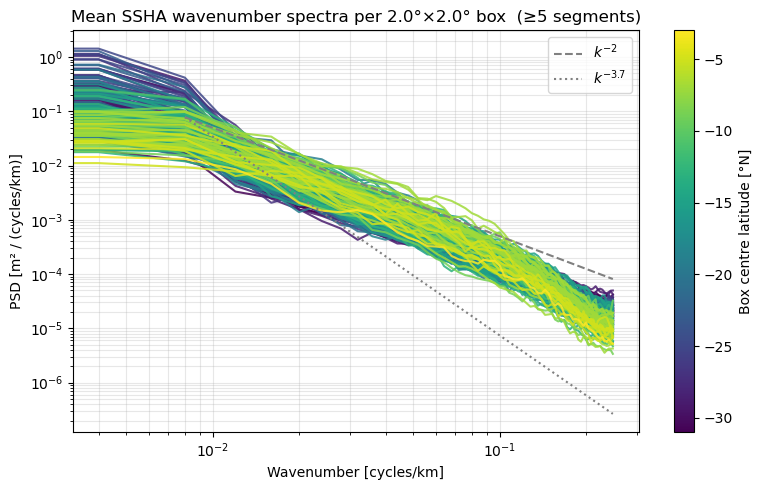

In [32]:
# Zoom in GS area
MIN_SEGMENTS_PER_BOX = 5

good_boxes = ds_boxes.where(ds_boxes["n_segments"] >= MIN_SEGMENTS_PER_BOX, drop=True)
good_boxes = good_boxes.where((good_boxes["lat_center"] >= LAT_MIN)&(good_boxes["lat_center"] <= 47), drop=True)
print(f"{good_boxes.sizes['box']} boxes with ≥ {MIN_SEGMENTS_PER_BOX} segments")

lat_vals = good_boxes["lat_center"].values
norm = plt.Normalize(vmin=lat_vals.min(), vmax=lat_vals.max())
cmap = plt.get_cmap("viridis")

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(good_boxes.sizes["box"]):
    box = good_boxes.isel(box=i)
    ax.loglog(box["wavenumber"], box["mean_psd"],
              color=cmap(norm(float(box["lat_center"]))),
              lw=1.5, alpha=0.85)

# Reference slopes
k_ref = good_boxes["wavenumber"].values[2:]
psd0  = float(good_boxes["mean_psd"].isel(box=0).values[2])
k0    = k_ref[0]
for exp, ls in ((-2, "--"), (-11/3, ":")):
    lbl = f"$k^{{{exp:.2g}}}$".replace("-3.67", "-11/3")
    ax.loglog(k_ref, psd0 * (k_ref / k0) ** exp, ls, color="gray", label=lbl)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Box centre latitude [°N]")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra per {BOX_DEG}°×{BOX_DEG}° box  "
             f"(≥{MIN_SEGMENTS_PER_BOX} segments)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

239 boxes with ≥ 5 segments


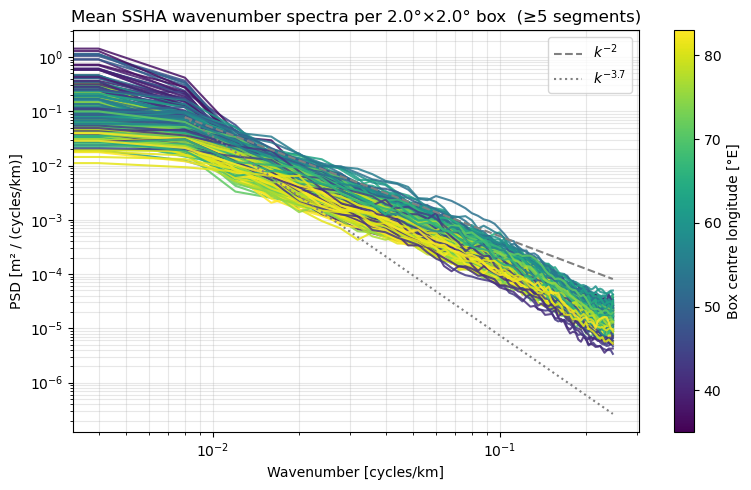

In [33]:
# This is the same than the first figure of the subsection but this time color correspond to different longitudes
MIN_SEGMENTS_PER_BOX = 5

good_boxes = ds_boxes.where(ds_boxes["n_segments"] >= MIN_SEGMENTS_PER_BOX, drop=True)
good_boxes = good_boxes.where((good_boxes["lat_center"] >= LAT_MIN)&(good_boxes["lat_center"] <= 47), drop=True)
print(f"{good_boxes.sizes['box']} boxes with ≥ {MIN_SEGMENTS_PER_BOX} segments")

lon_vals = good_boxes["lon_center"].values
norm = plt.Normalize(vmin=lon_vals.min(), vmax=lon_vals.max())
cmap = plt.get_cmap("viridis")

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(good_boxes.sizes["box"]):
    box = good_boxes.isel(box=i)
    ax.loglog(box["wavenumber"], box["mean_psd"],
              color=cmap(norm(float(box["lon_center"]))),
              lw=1.5, alpha=0.85)

# Reference slopes
k_ref = good_boxes["wavenumber"].values[2:]
psd0  = float(good_boxes["mean_psd"].isel(box=0).values[2])
k0    = k_ref[0]
for exp, ls in ((-2, "--"), (-11/3, ":")):
    lbl = f"$k^{{{exp:.2g}}}$".replace("-3.67", "-11/3")
    ax.loglog(k_ref, psd0 * (k_ref / k0) ** exp, ls, color="gray", label=lbl)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Box centre longitude [°E]")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra per {BOX_DEG}°×{BOX_DEG}° box  "
             f"(≥{MIN_SEGMENTS_PER_BOX} segments)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

## 12. Spectra: mean PSD per box averaged per latitude and longitude

Boxes with fewer than `MIN_SEGMENTS_PER_BOX` segments are excluded to avoid noisy estimates.

239 boxes with ≥ 5 segments


/Users/zoecas/miniconda3/envs/croco/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension lat_center because variable lat_center is not a coordinate. To create an index for lat_center, please first call `.set_coords('lat_center')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)


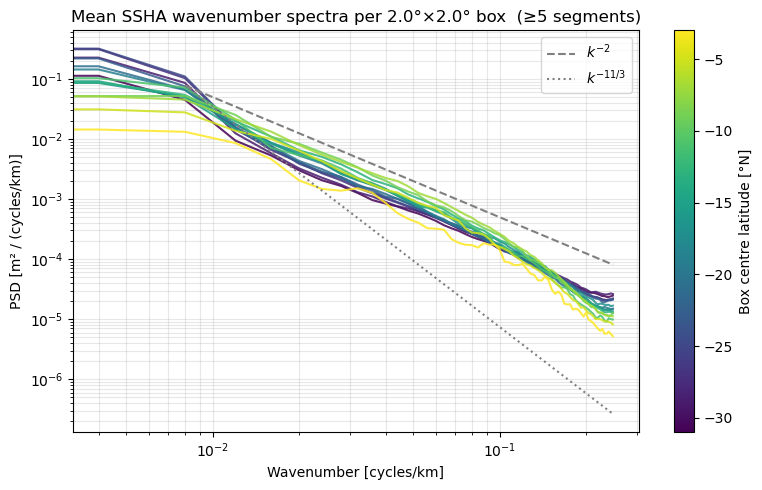

In [34]:
# Zonal average
MIN_SEGMENTS_PER_BOX = 5

good_boxes = ds_boxes.where(ds_boxes["n_segments"] >= MIN_SEGMENTS_PER_BOX, drop=True)
good_boxes = good_boxes.where((good_boxes["lat_center"] >= LAT_MIN)&(good_boxes["lat_center"] <= 47), drop=True)
print(f"{good_boxes.sizes['box']} boxes with ≥ {MIN_SEGMENTS_PER_BOX} segments")

lat_vals = good_boxes["lat_center"].values
norm = plt.Normalize(vmin=lat_vals.min(), vmax=lat_vals.max())
cmap = plt.get_cmap("viridis")

fig, ax = plt.subplots(figsize=(8, 5))
box = good_boxes.groupby('lat_center').mean()
#for i in range(good_boxes.sizes["box"]):
    #box = good_boxes.isel(box=i)
for i in range(box.sizes["lat_center"]):
    lat_box = box.isel(lat_center = i)
    ax.loglog(lat_box["wavenumber"], lat_box["mean_psd"],color=cmap(norm(float(lat_box["lat_center"]))),lw=1.5, alpha=0.85)

# Reference slopes
k_ref = good_boxes["wavenumber"].values[2:]
psd0  = float(good_boxes["mean_psd"].isel(box=0).values[2])
k0    = k_ref[0]
for exp, ls in ((-2, "--"), (-11/3, ":")):
    lbl = f"$k^{{{exp:.2g}}}$".replace("-3.7", "-11/3")
    ax.loglog(k_ref, psd0 * (k_ref / k0) ** exp, ls, color="gray", label=lbl)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Box centre latitude [°N]")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra per {BOX_DEG}°×{BOX_DEG}° box  "
             f"(≥{MIN_SEGMENTS_PER_BOX} segments)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

239 boxes with ≥ 5 segments


/Users/zoecas/miniconda3/envs/croco/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension lon_center because variable lon_center is not a coordinate. To create an index for lon_center, please first call `.set_coords('lon_center')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)


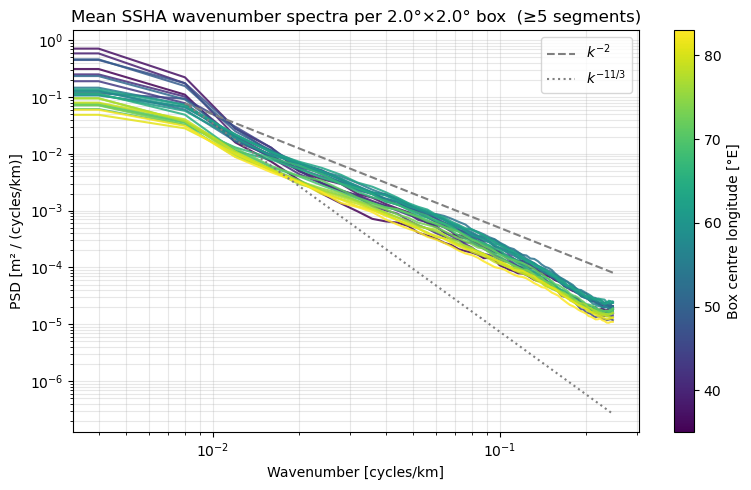

In [35]:
#Meridional average
MIN_SEGMENTS_PER_BOX = 5

good_boxes = ds_boxes.where(ds_boxes["n_segments"] >= MIN_SEGMENTS_PER_BOX, drop=True)
good_boxes = good_boxes.where((good_boxes["lat_center"] >= LAT_MIN)&(good_boxes["lat_center"] <= 47), drop=True)
print(f"{good_boxes.sizes['box']} boxes with ≥ {MIN_SEGMENTS_PER_BOX} segments")

lon_vals = good_boxes["lon_center"].values
norm = plt.Normalize(vmin=lon_vals.min(), vmax=lon_vals.max())
cmap = plt.get_cmap("viridis")

fig, ax = plt.subplots(figsize=(8, 5))
box = good_boxes.groupby('lon_center').mean()
#for i in range(good_boxes.sizes["box"]):
    #box = good_boxes.isel(box=i)
for i in range(box.sizes["lon_center"]):
    lon_box = box.isel(lon_center = i)
    ax.loglog(lon_box["wavenumber"], lon_box["mean_psd"],color=cmap(norm(float(lon_box["lon_center"]))),lw=1.5, alpha=0.85)

# Reference slopes
k_ref = good_boxes["wavenumber"].values[2:]
psd0  = float(good_boxes["mean_psd"].isel(box=0).values[2])
k0    = k_ref[0]
for exp, ls in ((-2, "--"), (-11/3, ":")):
    lbl = f"$k^{{{exp:.2g}}}$".replace("-3.7", "-11/3")
    ax.loglog(k_ref, psd0 * (k_ref / k0) ** exp, ls, color="gray", label=lbl)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Box centre longitude [°E]")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra per {BOX_DEG}°×{BOX_DEG}° box  "
             f"(≥{MIN_SEGMENTS_PER_BOX} segments)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

## 13. Dev cells

239 boxes with ≥ 5 segments


/Users/zoecas/miniconda3/envs/croco/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension lon_center because variable lon_center is not a coordinate. To create an index for lon_center, please first call `.set_coords('lon_center')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)


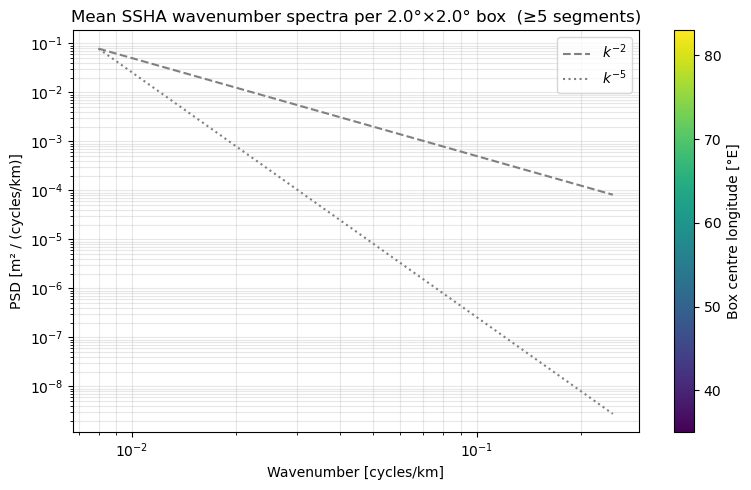

In [36]:
#Meridional average
MIN_SEGMENTS_PER_BOX = 5

good_boxes = ds_boxes.where(ds_boxes["n_segments"] >= MIN_SEGMENTS_PER_BOX, drop=True)
good_boxes = good_boxes.where((good_boxes["lat_center"] >= LAT_MIN)&(good_boxes["lat_center"] <= 47), drop=True)
print(f"{good_boxes.sizes['box']} boxes with ≥ {MIN_SEGMENTS_PER_BOX} segments")

lon_vals = good_boxes["lon_center"].values
norm = plt.Normalize(vmin=lon_vals.min(), vmax=lon_vals.max())
cmap = plt.get_cmap("viridis")

fig, ax = plt.subplots(figsize=(8, 5))
box = good_boxes.groupby('lon_center').mean()
box.sel(lon_center=slice(312,325)).mean_psd.mean('lon_center').plot(xscale='log',yscale='log')
box.sel(lon_center=slice(290,312)).mean_psd.mean('lon_center').plot(xscale='log',yscale='log')

# Reference slopes
k_ref = box["wavenumber"].values[2:]
psd0  = float(box["mean_psd"].mean('lon_center').values[2])
#psd1  = float(box["mean_psd"].values[2])
k0    = k_ref[0]
for exp, ls in ((-2, "--"), (-5, ":")):
    lbl = f"$k^{{{exp:.2g}}}$".replace("-3.67", "-11/3")
    ax.loglog(k_ref, psd0 * (k_ref[:] / k0) ** exp, ls, color="gray", label=lbl)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Box centre longitude [°E]")

ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra per {BOX_DEG}°×{BOX_DEG}° box  "
             f"(≥{MIN_SEGMENTS_PER_BOX} segments)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

In [27]:
box.sel(lon_center=slice(312,325)).mean_psd.mean('lon_center').plot(xscale='log',yscale='log')
box.sel(lon_center=slice(290,312)).mean_psd.mean('lon_center').plot(xscale='log',yscale='log')
plt.axvline(1/40);plt.axvline(1/5)

Error in callback <function _draw_all_if_interactive at 0x135686fb0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 640x480 with 1 Axes>

In [28]:
test0 = (box.sel(lon_center=slice(312,325),wavenumber=slice(1/50,1/5)).mean_psd.mean('lon_center'))
test1 = (box.sel(lon_center=slice(290,312),wavenumber=slice(1/50,1/5)).mean_psd.mean('lon_center'))


In [30]:
slope0 = np.log10(test0).diff('wavenumber')/np.log10(test0.wavenumber).diff('wavenumber')
slope1 = np.log10(test1).diff('wavenumber')/np.log10(test1.wavenumber).diff('wavenumber')

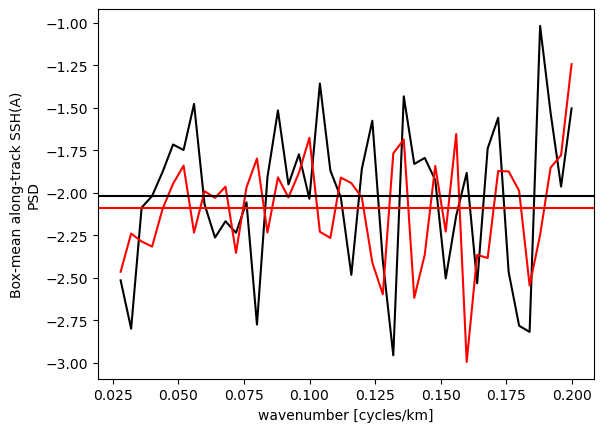

In [31]:
slope0.plot(c='k')
slope1.plot(c='r')
plt.axhline(slope0.mean(),c='k')
plt.axhline(slope1.mean(),c='r')
#plt.axhline(-2,c='k')
#plt.axhline(-11/3,c='k')
#plt.axhline(-5/3,c='k')

In [37]:
K_MIN, K_MAX = 1/30, 1/5  # cycles/km

k = ds_boxes["wavenumber"].values
k_mask = (k >= K_MIN) & (k <= K_MAX)
dk = np.gradient(k)

psd_vals = np.log10(ds_boxes["mean_psd"].values)          # (n_boxes, nk)
k_vals = np.log10(ds_boxes["wavenumber"].values)          # (n_boxes, nk)
slope_mean = np.nanmean(np.diff(psd_vals,axis=1)/np.diff(k_vals),axis=1)
#energy = np.nansum(psd_vals[:, k_mask] * dk[k_mask], axis=1)  # (n_boxes,)

/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_13447/1637026937.py:8: RuntimeWarning: divide by zero encountered in log10
  k_vals = np.log10(ds_boxes["wavenumber"].values)          # (n_boxes, nk)


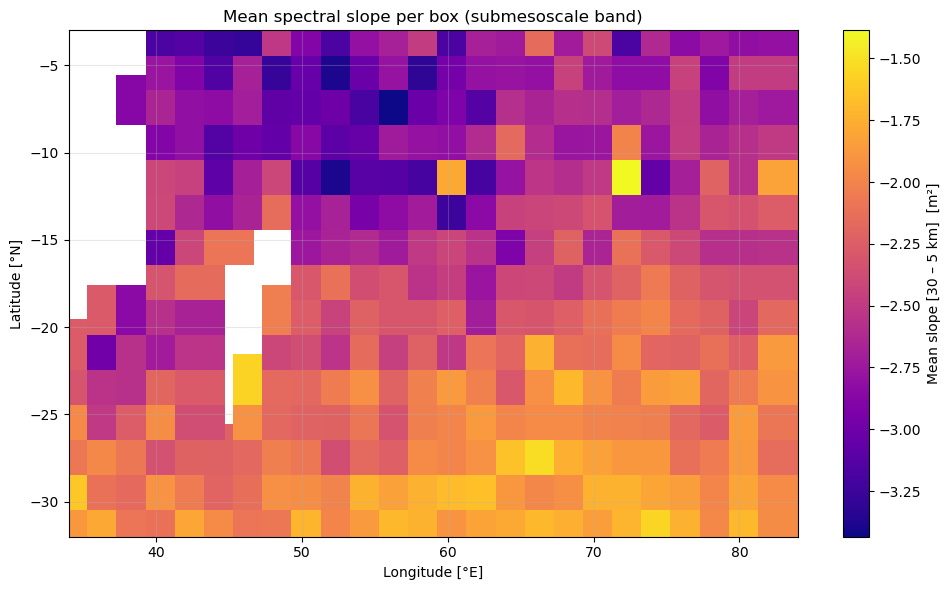

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    ds_boxes["lon_center"].values,
    ds_boxes["lat_center"].values,
    c=slope_mean,
    s=(BOX_DEG * 60) ** 1.5,
    marker="s",
    cmap="plasma",
    #norm=mcolors.LogNorm(vmin=np.nanpercentile(slope_mean, 5),
    #                      vmax=np.nanpercentile(slope_mean, 95)),
    edgecolors="none",
)
plt.colorbar(sc, ax=ax, label=f"Mean slope [{1/K_MIN:.0f} – {1/K_MAX:.0f} km]  [m²]")
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_xlabel("Longitude [°E]")
ax.set_ylabel("Latitude [°N]")
ax.set_title("Mean spectral slope per box (submesoscale band)")
ax.grid(True, alpha=0.3)
fig.tight_layout()

In [68]:
test_boxes = ds_boxes.where((ds_boxes.lat_center<=40)&(ds_boxes.lat_center>=25)
                            &(ds_boxes.lon_center<=330)&(ds_boxes.lon_center>=305),drop=True)

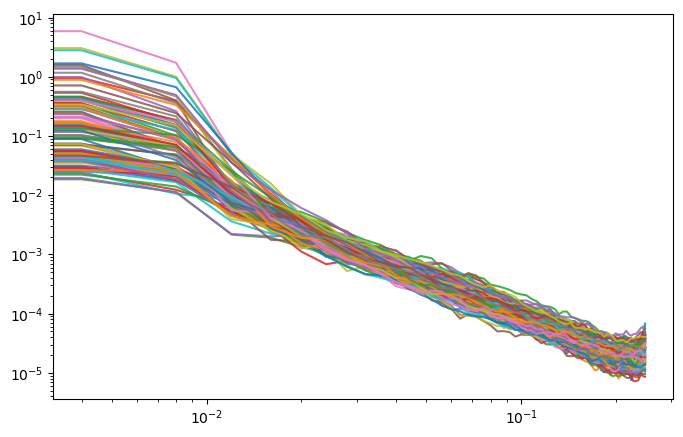

In [69]:
good_boxes = test_boxes.where(test_boxes["n_segments"] >= MIN_SEGMENTS_PER_BOX, drop=True)
fig, ax = plt.subplots(figsize=(8, 5))
for i in range(good_boxes.sizes["box"]):
    box = good_boxes.isel(box=i)
    ax.loglog(box["wavenumber"], box["mean_psd"],
              lw=1.5, alpha=0.85)

## 14. Save results

In [20]:
# ds_segments.to_netcdf("swot_expert_segments.nc")
# ds_boxes.to_netcdf("swot_expert_box_spectra.nc")